In [7]:
import sys
import os

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np

from datetime import datetime

from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output

from src.nca.utils import L2, make_seed, load_image
from src.nca.model import NCADish


In [8]:

def adapt_env(model, cs, target):
    length = np.random.randint(64, 96)

    for n in range(length):
        cs = model(cs)

    target_channel = target.shape[1]
    batch_loss, total_loss = L2(cs[:, :target_channel, ...], target)
    return batch_loss, total_loss, cs


In [9]:
model = NCADish(
    width = 28,
    height = 28,
    channels = 8,
    device="cuda"
)

In [10]:
target = load_image("../test_data/chest.png", size=28)
seed = make_seed(28,28)

board = model.seed(seed)
target = model.target(target)

In [11]:
def plot_loss(losses):
    clear_output(wait=True)  # clear the previous plot
    window_size = 20
    
    # Compute moving variance over sliding windows
    
    variance = [np.var(losses[n:n+window_size] - np.min(losses[n:n+window_size])/(np.max(losses[n:n+window_size]) - np.min(losses[n:n+window_size]))) for n in range(len(losses) - window_size)]
    
    # Create figure and subplots
    plt.figure(figsize=(15, 4))

    # --- 1. All losses ---
    plt.subplot(1, 3, 1)
    plt.plot(losses, color='tab:blue')
    plt.title("All Losses")
    plt.xlabel("Step")
    plt.ylabel("Loss")

    # --- 2. Windowed (recent) losses ---
    plt.subplot(1, 3, 2)
    plt.plot(losses[-200:], color='tab:orange')
    plt.title("Recent (Windowed) Losses")
    plt.xlabel("Step")
    plt.ylabel("Loss")

    # --- 3. Variance over windows ---
    plt.subplot(1, 3, 3)
    plt.plot(variance, color='tab:green')
    plt.title(f"Windowed Variance (window={window_size})")
    plt.xlabel("Step")
    plt.ylabel("Variance")

    plt.tight_layout()
    plt.show()

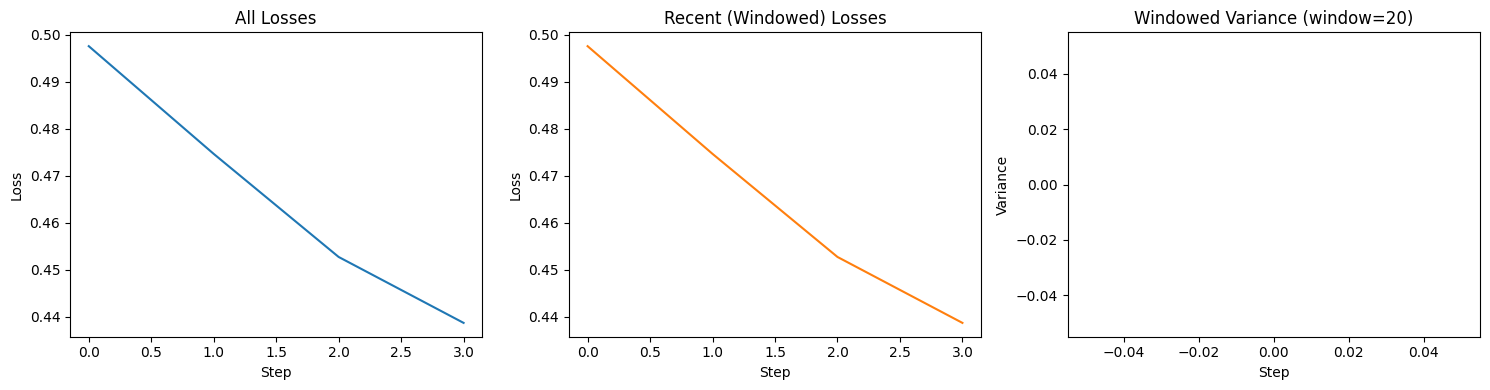

Epoch [4], Loss: 0.4387:   0%|          | 4/2500 [00:13<2:14:42,  3.24s/it]

In [ ]:
testable_model, avg_loss = model.grow(
    env=adapt_env,
    epochs=2500,
    learnign_rate=0.0002,
    pool_size=1024,
    loss_callback=plot_loss,
)

In [11]:
testable_model = model.get_latest_model()
frames = []
for n in range(96*3):
    # Example: list of frames (NumPy arrays)
    frame = testable_model(board)
    frame_np = frame[0,...].permute(1, 2, 0).cpu().detach().numpy()  # (H, W, C)
    frame_np = (frame_np[..., :4] * 255).astype(np.uint8)
    
    # Clear previous output and draw new frame
    clear_output(wait=True)
    plt.figure(figsize=(4, 4))
    plt.imshow(frame_np, cmap='plasma')
    plt.title(f"Step {n}")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.05)  # control playback speed (~20 FPS)

AttributeError: 'NCADish' object has no attribute 'get_latest_model'